# Annotation Pipeline — Exploratory Data Analysis

Basic EDA: data distribution, per-category accuracy heatmap, and inter-annotator disagreement analysis.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import compute_consensus, CATEGORIES, ANNOTATOR_COLS

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 80)

In [2]:
df = pd.read_csv('../data/annotations_all.csv')
print(f'Dataset: {len(df)} items, {df.columns.tolist()}')
df.head()

Dataset: 1000 items, ['item_id', 'text', 'true_label', 'annotator_1', 'annotator_2', 'annotator_3', 'annotator_4', 'annotator_5', 'llm_annotator', 'consensus']


,item_id,text,true_label,annotator_1,annotator_2,annotator_3,annotator_4,annotator_5,llm_annotator,consensus
0,0,CEO Eisner to Step Down in Sept 2006 -WSJ NEW YORK (Reuters) - Michael Eisn...,Business,Business,Sci/Tech,Business,Business,Business,Business,Business
1,1,"Technology ; STT, Telekom Malaysia buy 48 pct of Idea Singapore government-o...",Business,Business,Sci/Tech,Business,Business,Business,Business,Business
2,2,"Guilty Plea Seen in Computer Associates Case Steven Woghin, the former gener...",Business,Business,Business,Business,Business,Business,Business,Business
3,3,Coke opens its coolers to rival products Coca Cola is to allow other compani...,Business,Business,Business,Business,Business,Business,Business,Business
4,4,#39;Noles Rebound Leon Washington ran for 104 yards and a touchdown and Flo...,Sports,Sports,Sports,Sports,Sports,World,Sports,Sports


## 1. Data Distribution

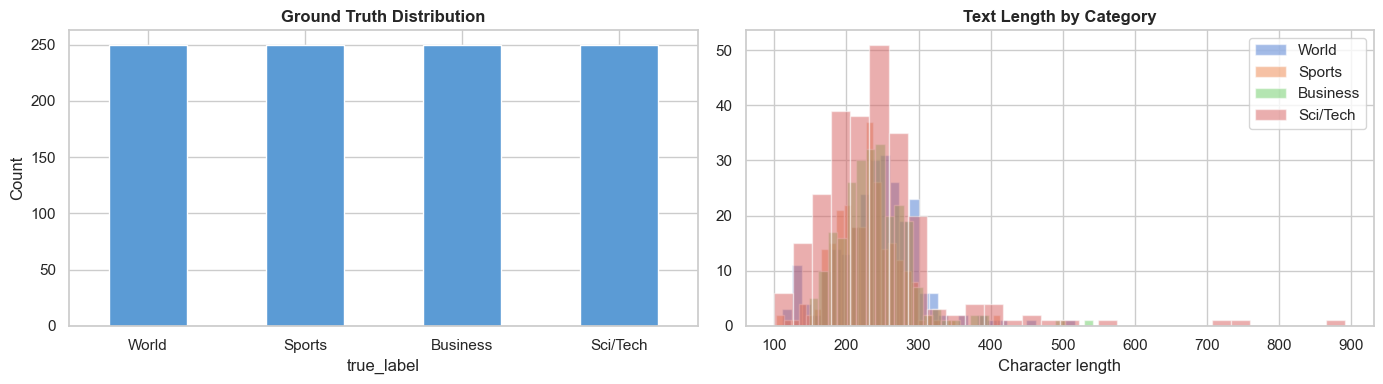

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Ground truth distribution
df['true_label'].value_counts().reindex(CATEGORIES).plot.bar(
    ax=axes[0], color='#5B9BD5', edgecolor='white')
axes[0].set_title('Ground Truth Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Text length distribution by category
df['text_len'] = df['text'].str.len()
for cat in CATEGORIES:
    subset = df[df['true_label'] == cat]['text_len']
    axes[1].hist(subset, bins=30, alpha=0.5, label=cat)
axes[1].set_title('Text Length by Category', fontweight='bold')
axes[1].set_xlabel('Character length')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Per-Category Accuracy Heatmap

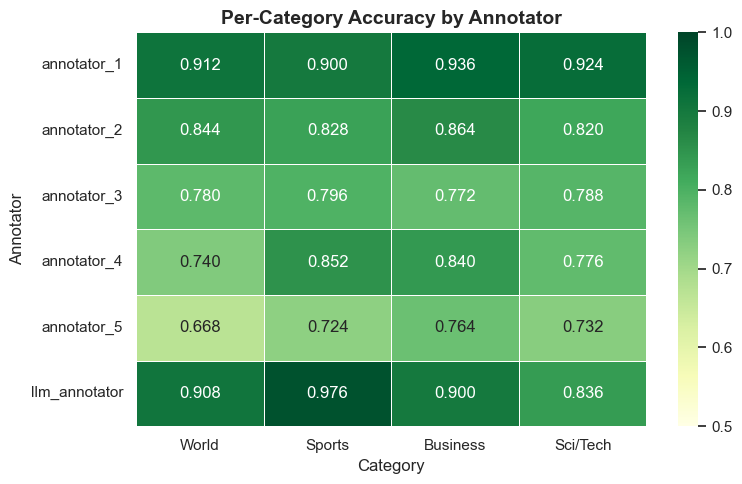


Accuracy table:


,World,Sports,Business,Sci/Tech
annotator_1,0.912,0.900,0.936,0.924
annotator_2,0.844,0.828,0.864,0.820
annotator_3,0.780,0.796,0.772,0.788
annotator_4,0.740,0.852,0.840,0.776
annotator_5,0.668,0.724,0.764,0.732
llm_annotator,0.908,0.976,0.900,0.836


In [4]:
# Build per-annotator, per-category accuracy matrix
all_cols = ANNOTATOR_COLS[:]
if 'llm_annotator' in df.columns and df['llm_annotator'].notna().all():
    all_cols.append('llm_annotator')

acc_matrix = pd.DataFrame(index=all_cols, columns=CATEGORIES, dtype=float)
for col in all_cols:
    for cat in CATEGORIES:
        mask = df['true_label'] == cat
        acc_matrix.loc[col, cat] = (df.loc[mask, col] == cat).mean()

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(acc_matrix.astype(float), annot=True, fmt='.3f', cmap='YlGn',
            vmin=0.5, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title('Per-Category Accuracy by Annotator', fontsize=14, fontweight='bold')
ax.set_ylabel('Annotator')
ax.set_xlabel('Category')
plt.tight_layout()
plt.show()

print('\nAccuracy table:')
acc_matrix

## 3. Inter-Annotator Disagreement Analysis

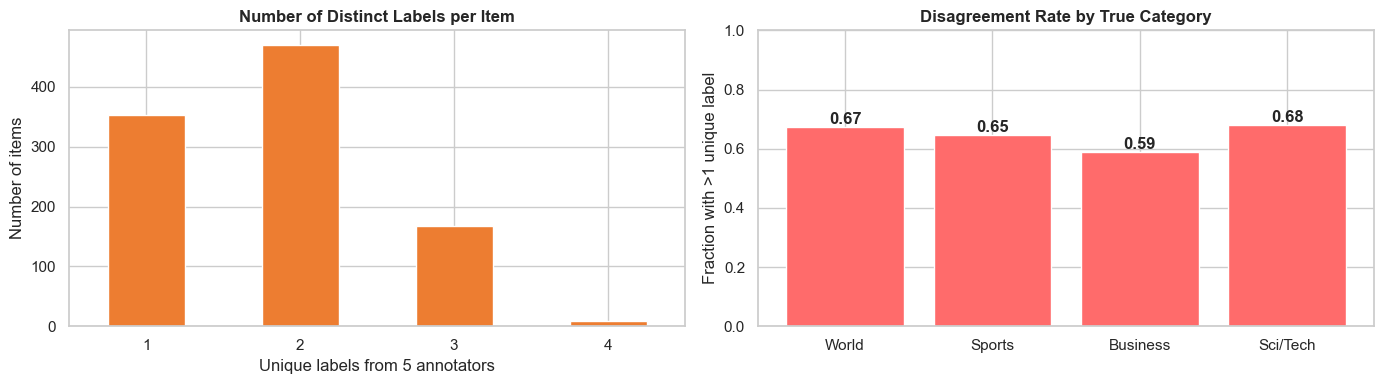

In [5]:
# Count how many unique labels each item received from human annotators
df['n_unique_labels'] = df[ANNOTATOR_COLS].nunique(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of agreement levels
df['n_unique_labels'].value_counts().sort_index().plot.bar(
    ax=axes[0], color='#ED7D31', edgecolor='white')
axes[0].set_title('Number of Distinct Labels per Item', fontweight='bold')
axes[0].set_xlabel('Unique labels from 5 annotators')
axes[0].set_ylabel('Number of items')
axes[0].tick_params(axis='x', rotation=0)

# Disagreement rate by category
disagree_rate = []
for cat in CATEGORIES:
    mask = df['true_label'] == cat
    rate = (df.loc[mask, 'n_unique_labels'] > 1).mean()
    disagree_rate.append(rate)

axes[1].bar(CATEGORIES, disagree_rate, color='#FF6B6B', edgecolor='white')
axes[1].set_title('Disagreement Rate by True Category', fontweight='bold')
axes[1].set_ylabel('Fraction with >1 unique label')
for i, r in enumerate(disagree_rate):
    axes[1].text(i, r + 0.01, f'{r:.2f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

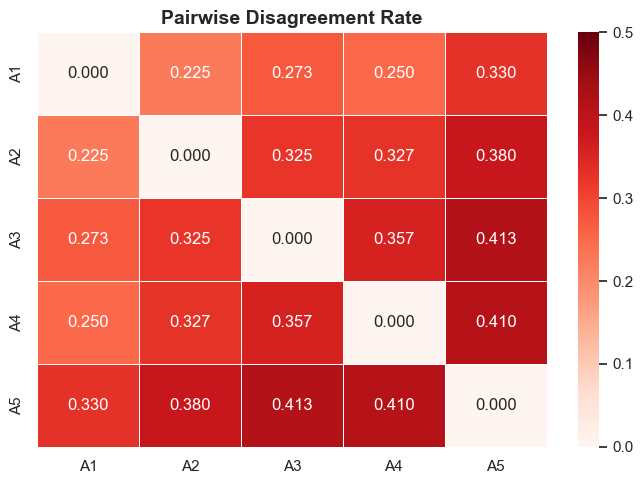

In [6]:
# Pairwise disagreement matrix (fraction of items where two annotators disagree)
from itertools import combinations

cols = ANNOTATOR_COLS[:]
n = len(cols)
disagree_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
for a, b in combinations(cols, 2):
    rate = (df[a] != df[b]).mean()
    disagree_matrix.loc[a, b] = rate
    disagree_matrix.loc[b, a] = rate

fig, ax = plt.subplots(figsize=(7, 5))
labels = [c.replace('annotator_', 'A') for c in cols]
sns.heatmap(disagree_matrix.values.astype(float), annot=True, fmt='.3f',
            xticklabels=labels, yticklabels=labels,
            cmap='Reds', vmin=0, vmax=0.5, ax=ax, linewidths=0.5)
ax.set_title('Pairwise Disagreement Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Items with highest disagreement — what do they look like?
high_disagree = df[df['n_unique_labels'] >= 3].sort_values('n_unique_labels', ascending=False)
print(f'Items with 3+ unique labels: {len(high_disagree)}')
print()
for _, row in high_disagree.head(10).iterrows():
    votes = {c.replace('annotator_', 'A'): row[c] for c in ANNOTATOR_COLS}
    print(f'[{row["true_label"]:8s}] {row["text"][:100]}')
    print(f'           Votes: {votes}')
    if 'llm_annotator' in df.columns:
        print(f'           LLM:   {row["llm_annotator"]}')
    print()

Items with 3+ unique labels: 176

[Business] Time warner in \$600m setttlement Time Warner is to announce today that it will pay between \$500 an
           Votes: {'A1': 'World', 'A2': 'Sports', 'A3': 'Business', 'A4': 'Sci/Tech', 'A5': 'Business'}
           LLM:   Business

[Sports  ] ROSSI CELEBRATES IN STYLE Valentino Rossi hailed an  quot;unbelievable quot; season after celebratin
           Votes: {'A1': 'World', 'A2': 'Business', 'A3': 'Sports', 'A4': 'Sci/Tech', 'A5': 'Sports'}
           LLM:   Sports

[World   ] Hurricane Ivan Roars Toward Gulf Coast NEW ORLEANS - Stragglers streamed toward higher ground Wednes
           Votes: {'A1': 'World', 'A2': 'Sports', 'A3': 'Business', 'A4': 'World', 'A5': 'Sci/Tech'}
           LLM:   World

[Sports  ] Finley is new Angel in outfield The Angels rounded out their starting outfield yesterday, signing ce
           Votes: {'A1': 'Sports', 'A2': 'Business', 'A3': 'Sci/Tech', 'A4': 'Sports', 'A5': 'World'}
           LLM:   Sports

[Spo

In [8]:
# Summary statistics
consensus = compute_consensus(df)
print('=== Summary ===')
print(f'Total items: {len(df)}')
print(f'Items with full agreement (1 unique label): {(df["n_unique_labels"] == 1).sum()}')
print(f'Items with some disagreement (2+ labels):   {(df["n_unique_labels"] >= 2).sum()}')
print(f'Items with high disagreement (3+ labels):   {(df["n_unique_labels"] >= 3).sum()}')
print(f'Consensus accuracy: {(consensus == df["true_label"]).mean():.4f}')
if 'llm_annotator' in df.columns and df['llm_annotator'].notna().all():
    print(f'LLM accuracy:       {(df["llm_annotator"] == df["true_label"]).mean():.4f}')

=== Summary ===
Total items: 1000
Items with full agreement (1 unique label): 353
Items with some disagreement (2+ labels):   647
Items with high disagreement (3+ labels):   176
Consensus accuracy: 0.9700
LLM accuracy:       0.9050
